# Running t-test

In this notebook, a t-test is run to identify the most statistically important genes in order to choose a subset of features for model training. 

In [1]:
import numpy as np
import pandas as pd

from scipy.stats import ttest_ind
from statsmodels.stats.multitest import multipletests

import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
# Define paths
path = ['./X_train.csv', './y_train.csv']

w_path = path[0]
clusters_path = path[1]

path = ['./X_train.csv', './y_train.csv']
# W_df, clusters = [pd.read_csv(f, index_col=0) for f in path]

W_df = pd.read_csv(w_path, index_col=0)
clusters = pd.read_csv(clusters_path, index_col=0)

print("W_df shape:", W_df.shape)
display(W_df.head())

print("clusters shape:", clusters.shape)
display(clusters.head())

# Confirm indices align
common = W_df.index.intersection(clusters.index)
print(f"Common sample IDs: {len(common)} / {len(W_df)}")
# if not equal, show differences
if len(common) != len(W_df):
    print("Samples not fully aligned. Example W_df-only samples:", list(set(W_df.index) - set(clusters.index))[:5])
    print("clusters-only samples:", list(set(clusters.index) - set(W_df.index))[:5])

W_df shape: (610, 18644)


,A1BG,A1CF,A2BP1,A2LD1,A2M,A2ML1,A3GALT2,A4GALT,A4GNT,AAA1,...,ZXDA,ZXDB,ZXDC,ZYG11A,ZYG11B,ZYX,ZZEF1,ZZZ3,selenoprotein 15,tAKR
GSM8519814,12.93,11.345,3.570,7.29,12.34,3.605,4.43,4.215,4.93,3.320,...,4.54,5.595,6.975,3.450,7.005,7.880,7.540,7.910,11.01,6.26
GSM8520051,13.32,10.670,3.600,5.80,13.37,3.420,4.33,4.295,5.13,3.530,...,4.56,5.695,7.360,3.285,6.425,7.880,7.385,7.625,11.07,4.94
GSM8520123,11.86,10.145,3.775,6.44,12.41,3.740,4.63,4.190,5.28,3.740,...,4.76,5.510,5.930,3.425,6.450,7.825,7.010,7.270,11.34,5.86
GSM8519780,13.20,11.190,3.475,6.04,12.57,3.175,4.24,4.225,4.96,3.460,...,4.42,5.210,6.870,3.265,7.105,7.920,7.410,7.755,10.95,6.16
GSM8519656,13.07,11.280,3.595,7.59,12.74,3.550,4.26,4.155,5.15,3.705,...,4.43,5.435,6.695,3.465,7.245,7.305,7.355,8.125,11.03,6.97


clusters shape: (610, 1)


,Cluster
Sample,
GSM8519814,0
GSM8520051,0
GSM8520123,1
GSM8519780,0
GSM8519656,0


Common sample IDs: 610 / 610


In [ ]:
X_train = W_df.copy()
y_train = clusters.copy()
y_train=np.array(y_train['Cluster'])

print("Aligned shapes:", X_train.shape, y_train.shape)

Aligned shapes: (610, 18644) (610,)


In [19]:
group0 = X_train.loc[y_train == 0]  # all rows where y_train == 0
group1 = X_train.loc[y_train == 1]  # all rows where y_train == 1

print(group0)
print(group1)

             A1BG    A1CF  A2BP1  A2LD1    A2M  A2ML1  A3GALT2  A4GALT  A4GNT  \
GSM8519814  12.93  11.345  3.570   7.29  12.34  3.605     4.43   4.215   4.93   
GSM8520051  13.32  10.670  3.600   5.80  13.37  3.420     4.33   4.295   5.13   
GSM8519780  13.20  11.190  3.475   6.04  12.57  3.175     4.24   4.225   4.96   
GSM8519656  13.07  11.280  3.595   7.59  12.74  3.550     4.26   4.155   5.15   
GSM8519759  13.31  10.670  3.685   6.06  12.68  3.555     4.27   4.350   5.00   
...           ...     ...    ...    ...    ...    ...      ...     ...    ...   
GSM8520247   9.13   7.920  4.735   5.91   9.52  5.235     5.47   7.320   6.77   
GSM8519603  13.10  11.170  3.650   7.00  12.83  3.520     4.31   4.445   5.09   
GSM8519887  13.27  11.525  3.680   6.73  11.82  3.740     4.51   4.485   5.07   
GSM8519870  13.05  11.105  3.695   6.48  13.06  3.675     4.58   4.255   5.06   
GSM8520015  13.20  11.330  3.610   6.64  12.25  3.530     4.43   4.280   5.09   

             AAA1  ...  ZXD

In [ ]:
# X_train: pandas DataFrame, shape (600, 18000)
# y_train: array-like of 0s and 1s, length 600

# Split data by class
group0 = X_train.iloc[y_train == 0]
group1 = X_train.iloc[y_train == 1]

# Perform Welch’s t-test per gene (unequal variance)
t_vals, p_vals = ttest_ind(group1, group0, axis=0, equal_var=False, nan_policy='omit')

# Adjust p-values using Benjamini–Hochberg (FDR)
p_adj = multipletests(p_vals, method='fdr_bh')[1]

# Build result dataframe
results = pd.DataFrame({
    'gene': X_train.columns,
    't_stat': t_vals,
    'p_value': p_vals,
    'p_adj': p_adj
})

# Rank by adjusted p-value ascending (most significant at top)
results = results.sort_values(by='p_adj', ascending=True).reset_index(drop=True)

# Display top 10 most statistically significant genes
print(results.head(10))


     gene     t_stat       p_value         p_adj
0    GZMA  23.770561  2.429511e-74  4.529580e-70
1   ADCY7  20.589832  2.043084e-69  1.904562e-65
2    LCP2  21.997628  4.298672e-68  2.671482e-64
3   KLRK1  22.113577  4.470128e-65  2.083526e-61
4     FYB  21.869784  1.100659e-64  4.104138e-61
5    GZMK  21.353735  3.383186e-62  1.051269e-58
6    CD48  21.717227  4.983136e-62  1.327223e-58
7    TARP  20.103513  6.866612e-62  1.600264e-58
8  DOCK10  20.633355  8.092335e-62  1.676372e-58
9    CD53  20.665425  1.216817e-61  2.268634e-58


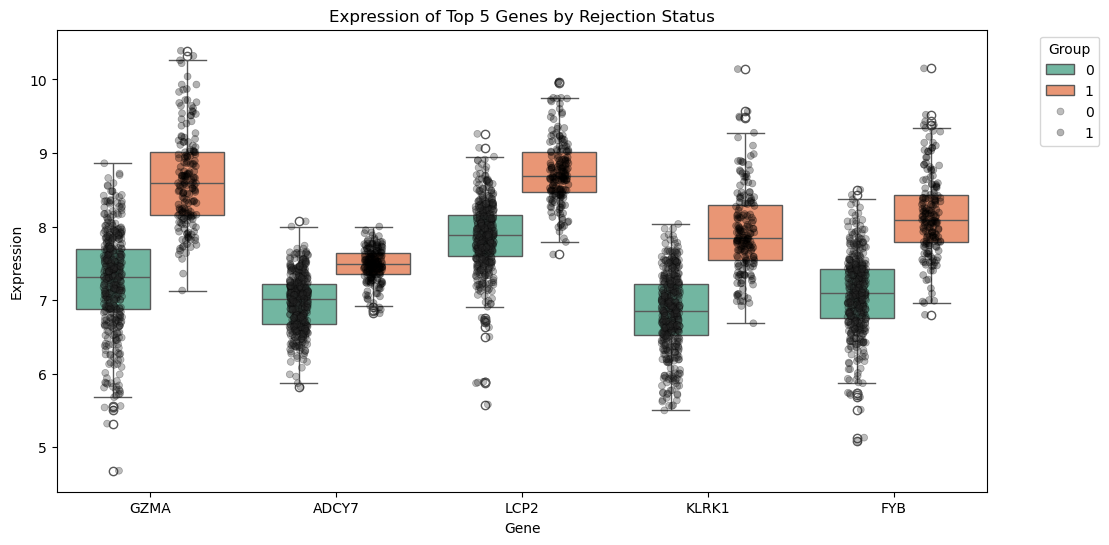

t_results saved successfully!


In [ ]:
# Select top 5 genes by adjusted p-value
# results: your t-test DataFrame, already sorted by 'p_adj'
top5_genes = results['gene'].head(5).tolist()

# Subset the expression data
top5_data = X_train[top5_genes].copy()

# Add group column
top5_data['Group'] = y_train


df_melt = top5_data.melt(id_vars='Group', 
                          value_vars=top5_genes, 
                          var_name='Gene', 
                          value_name='Expression')



# Boxplot
plt.figure(figsize=(12,6))
sns.boxplot(data=df_melt, x='Gene', y='Expression', hue='Group', palette='Set2')

# Stripplot overlay without deprecated color argument
sns.stripplot(data=df_melt, x='Gene', y='Expression', hue='Group', 
              dodge=True, palette='dark:black', alpha=0.3, linewidth=0.5, marker='o')

plt.title('Expression of Top 5 Genes by Rejection Status')
plt.ylabel('Expression')
plt.legend(title='Group', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

# Save t-test results to CSV
results.to_csv("./t_results_full.csv", index=False)
print("t_results saved successfully!")


In [24]:
# Load t-test results
t_results = pd.read_csv("./t_results_full.csv")  
t_results.head()

,gene,t_stat,p_value,p_adj
0,GZMA,23.770561,2.429511e-74,4.529580e-70
1,ADCY7,20.589832,2.043084e-69,1.904562e-65
2,LCP2,21.997628,4.298672e-68,2.671482e-64
3,KLRK1,22.113577,4.470128e-65,2.083526e-61
4,FYB,21.869784,1.100659e-64,4.104138e-61


# Graphing how the adjusted p-value changes 

In graphing how the p-value changes, we can potentially choose a cut-off point for which genes to keep. 

(0.0, 1000.0)

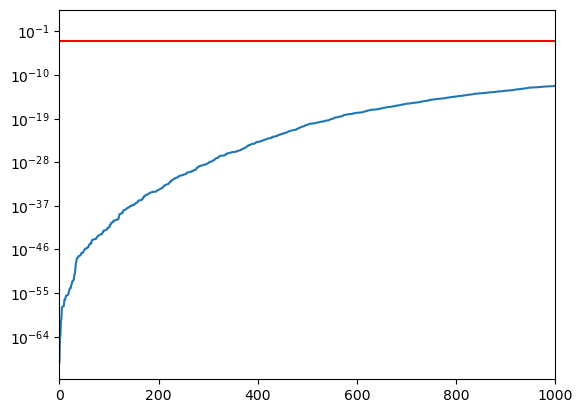

In [44]:
plt.semilogy(np.arange(t_results['p_adj'].shape[0]), t_results['p_adj'])
# plt.semilogy(np.arange(t_results['p_adj'].shape[0]), t_results.sort_values(by='p_adj', ascending=False)['p_adj'])

plt.axhline(0.001, c='r')
plt.axvline(2000, color='r')
plt.xlim((0,1000))

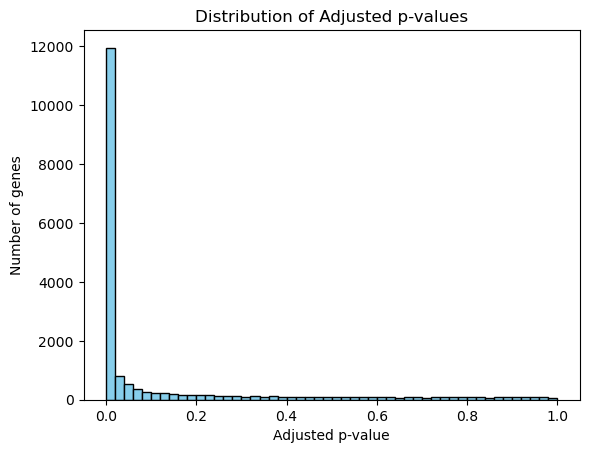

In [ ]:
plt.hist(results['p_adj'], bins=50, color='skyblue', edgecolor='black')
plt.xlabel('Adjusted p-value')
plt.ylabel('Number of genes')
plt.title('Distribution of Adjusted p-values')
plt.show()


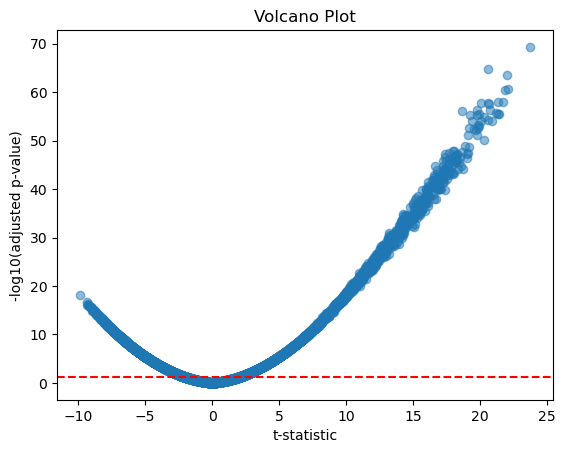

In [ ]:
plt.scatter(results['t_stat'], -np.log10(results['p_adj']), alpha=0.5)
plt.axhline(-np.log10(0.05), color='red', linestyle='--')  # typical FDR cutoff
plt.xlabel('t-statistic')
plt.ylabel('-log10(adjusted p-value)')
plt.title('Volcano Plot')
plt.show()


In [ ]:
top_400_genes = t_results['gene'].head(400).tolist()
print(top_400_genes)
X_train[top_400_genes]

pd.DataFrame(top_400_genes).to_csv('top_400_genes.csv')

['GZMA', 'ADCY7', 'LCP2', 'KLRK1', 'FYB', 'GZMK', 'CD48', 'TARP', 'DOCK10', 'CD53', 'IL2RB', 'PTGER4', 'HLA-DRA', 'RUNX3', 'RAC2', 'CD3D', 'GIMAP4', 'GIMAP2', 'CASP1', 'PTPRC', 'GBP5', 'CCL5', 'TRBC1', 'HLA-DPB1', 'GIMAP7', 'LCP1', 'DOCK2', 'CD52', 'GPR65', 'CD2', 'CXCR6', 'LY75', 'LCK', 'EOMES', 'PRKCB', 'HLA-DMB', 'SAMSN1', 'ARHGDIB', 'HLA-DPA1', 'IL23A', 'TRAF3IP3', 'CTSS', 'AOAH', 'PLEK', 'HLA-DMA', 'LAPTM5', 'CD247', 'CD72', 'GPR18', 'PSMB9', 'IPCEF1', 'RHOH', 'FGL2', 'ZC3H12D', 'TAP1', 'ST8SIA4', 'SRGN', 'AIM2', 'NLRC5', 'C16orf54', 'TNFAIP8', 'TNFSF13B', 'CCL4', 'CLEC2D', 'CD74', 'ARHGAP15', 'GBP2', 'CORO1A', 'ITK', 'APOBEC3G', 'HLA-DRB1', 'CYBB', 'CLEC2B', 'IRF8', 'DOCK11', 'SAMD9L', 'HCST', 'ARHGAP30', 'GPR171', 'BLVRA', 'CD8A', 'ITGAL', 'CMTM7', 'CYBA', 'PVRIG', 'BCL11B', 'CXCL9', 'LPCAT2', 'EVI2B', 'CD27', 'GIMAP5', 'AIF1', 'SLC7A7', 'ARAP2', 'FCER1G', 'ARHGEF3', 'TMSB10', 'IDO1', 'PYHIN1', 'CARD16', 'ITM2A', 'HLA-E', 'CD38', 'CXCL11', 'FCN1', 'DENND2D', 'PLEKHO1', 'BTN3A2',